# Fast Food Nutrition and Calorie Prediction Analysis
This project aims to develop and evaluate machine learning models to predict calorie content based on nutritional attributes from various fast-food items.  
The dataset includes menu items from multiple fast-food chains with their corresponding macronutrients and calorie information.

**Dataset:** Fast Food Nutrition Menu V3  
**Source:** Kaggle (Public Dataset)  
**File:** FastFoodNutritionMenuV3.csv

## Loading and Inspecting the Dataset
We begin by loading the dataset, inspecting its structure, and identifying data types, missing values, and potential quality issues.

In [5]:
#importing libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score#

#loading the dataset
data = pd.read_csv("FastFoodNutritionMenuV3.csv")

## Data Preprocessing
We perform encoding, handle missing values, and standardize column names for consistency.

In [37]:
#initialize label encoder
le = LabelEncoder()
categorical_cols = ['Item']
label_encoder = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[f'{col}_encoded'] = le.fit_transform(data[col])
    label_encoder[col] = le

#encode 'Item' column
data['Item_Encoded'] = le.fit_transform(data['Item'])
print("Item = Number Mapping:")
for i, category in enumerate(le.classes_):
    print(f"{category}: {i}")

#encode 'Company' column
data['Company_Encoded'] = le.fit_transform(data['Company'])
print("Company = Number Mapping:")
for i, category in enumerate(le.classes_):
    print(f"{category}: {i}")

Item = Number Mapping:
 Quarter Pounder® with Cheese: 0
1% Chocolate Milk: 1
1% Low Fat Chocolate Milk (8 fl oz): 2
1% Low Fat Chocolate Milk Jug: 3
1% Low Fat Milk Jug: 4
1% White Milk: 5
10 Piece Chicken Nuggets: 6
16 fl oz: 7
20 fl oz: 8
29 fl oz: 9
3 Piece Chicken Tenders: 10
38 fl oz: 11
4 Piece Chicken McNuggets Happy Meal: 12
4 Piece Chicken Nuggets: 13
4 Piece Chicken Tenders: 14
40 fl oz: 15
6 Picece Chicken Nuggets: 16
6 Piece Chicken McNuggets® Happy Meal: 17
6 Piece Chicken Tenders: 18
7-Up (16 fl oz): 19
7-Up (20 fl oz): 20
7-Up (30 fl oz): 21
7UP® (12 fl oz): 22
7UP® (16 fl oz): 23
7UP® (20 fl oz): 24
7UP® (30 fl oz): 25
All-Natural Lemonade, Large: 26
All-Natural Lemonade, Medium: 27
All-Natural Lemonade, Small: 28
American Cheese (slice): 29
Angus Bacon & Cheese: 30
Angus Bacon & Cheese Snack Wrap: 31
Angus Chipotle BBQ Bacon: 32
Angus Chipotle BBQ Bacon Snack Wrap: 33
Angus Deluxe: 34
Angus Deluxe Snack Wrap: 35
Angus Mushroom & Swiss: 36
Angus Mushroom & Swiss Snack W

In [7]:
data.head()

,Company,Item,Calories,Calories from\nFat,Total Fat\n(g),Saturated Fat\n(g),Trans Fat\n(g),Cholesterol\n(mg),Sodium \n(mg),Carbs\n(g),Fiber\n(g),Sugars\n(g),Protein\n(g),Weight Watchers\nPnts,Item_encoded,Item_Encoded,Company_Encoded
0,McDonald’s,Hamburger,250,80,9,3.5,0.5,25,520,31,2,6,12,247.5,420,420,2
1,McDonald’s,Cheeseburger,300,110,12,6,0.5,40,750,33,2,6,15,297,186,186,2
2,McDonald’s,Double Cheeseburger,440,210,23,11,1.5,80,1150,34,2,7,25,433,340,340,2
3,McDonald’s,McDouble,390,170,19,8,1,65,920,33,2,7,22,383,659,659,2
4,McDonald’s,Quarter Pounder® with Cheese,510,230,26,12,1.5,90,1190,40,3,9,29,502,0,0,2


In [8]:
data.tail()

,Company,Item,Calories,Calories from\nFat,Total Fat\n(g),Saturated Fat\n(g),Trans Fat\n(g),Cholesterol\n(mg),Sodium \n(mg),Carbs\n(g),Fiber\n(g),Sugars\n(g),Protein\n(g),Weight Watchers\nPnts,Item_encoded,Item_Encoded,Company_Encoded
1142,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Me...,230,NaN,10,4.5,0,25,390,25,2,1,11,NaN,452,452,3
1143,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Large,310,NaN,13,6,0,35,540,33,2,1,15,NaN,451,451,3
1144,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Small,120,NaN,4,1.5,0,10,230,17,1,1,5,NaN,456,456,3
1145,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Medium,200,NaN,6,2.5,0,15,370,27,2,2,8,NaN,455,455,3
1146,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Large,260,NaN,9,4,0,20,510,36,3,3,11,NaN,454,454,3


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1147 entries, 0 to 1146
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Company               1147 non-null   object
 1   Item                  1147 non-null   object
 2   Calories              1147 non-null   object
 3   Calories from
Fat     642 non-null    object
 4   Total Fat
(g)         1091 non-null   object
 5   Saturated Fat
(g)     1091 non-null   object
 6   Trans Fat
(g)         1091 non-null   object
 7   Cholesterol
(mg)      1147 non-null   object
 8   Sodium 
(mg)          1147 non-null   object
 9   Carbs
(g)             1091 non-null   object
 10  Fiber
(g)             1091 non-null   object
 11  Sugars
(g)            1147 non-null   object
 12  Protein
(g)           1091 non-null   object
 13  Weight Watchers
Pnts  887 non-null    object
 14  Item_encoded          1147 non-null   int64 
 15  Item_Encoded          1147 non-null   

In [10]:
data.shape

(1147, 17)

In [11]:
data.dtypes

Company                  object
Item                     object
Calories                 object
Calories from\nFat       object
Total Fat\n(g)           object
Saturated Fat\n(g)       object
Trans Fat\n(g)           object
Cholesterol\n(mg)        object
Sodium \n(mg)            object
Carbs\n(g)               object
Fiber\n(g)               object
Sugars\n(g)              object
Protein\n(g)             object
Weight Watchers\nPnts    object
Item_encoded              int64
Item_Encoded              int64
Company_Encoded           int64
dtype: object

In [12]:
data.describe(include='all')


,Company,Item,Calories,Calories from\nFat,Total Fat\n(g),Saturated Fat\n(g),Trans Fat\n(g),Cholesterol\n(mg),Sodium \n(mg),Carbs\n(g),Fiber\n(g),Sugars\n(g),Protein\n(g),Weight Watchers\nPnts,Item_encoded,Item_Encoded,Company_Encoded
count,1147,1147,1147,642,1091,1091,1091,1147,1147,1091,1091,1147,1091,887,1147.000000,1147.000000,1147.000000
unique,6,1071,105,64,73,35,11,65,214,131,17,122,56,524,NaN,NaN,NaN
top,McDonald’s,20 fl oz,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
freq,328,11,83,175,357,383,954,378,54,75,551,190,314,67,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,517.829119,517.829119,2.265039
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,318.812134,318.812134,1.641900
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,241.500000,241.500000,1.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,511.000000,511.000000,2.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,797.500000,797.500000,4.000000


In [13]:
#check for missing values
data.isnull().sum()

#fill missing numeric values with column mean, categorical with mode
num_cols = data.select_dtypes(include=np.number).columns
cat_cols = data.select_dtypes(exclude=np.number).columns

data[num_cols] = data[num_cols].fillna(data[num_cols].mean())


In [38]:
#clean column names (remove \n, spaces, parentheses)
data.columns = (
    data.columns
    .str.replace('\n', '_', regex=True)
    .str.replace(' ', '_', regex=True)
    .str.replace(r'\(.*\)', '', regex=True)
    .str.strip()
)

print("Cleaned column names:")
print(*data.columns, sep="\n")

Cleaned column names:
Company
Item
Calories
Calories_from_Fat
Total_Fat_
Saturated_Fat_
Trans_Fat_
Cholesterol_
Sodium__
Carbs_
Fiber_
Sugars_
Protein_
Weight_Watchers_Pnts
Item_encoded
Item_Encoded
Company_Encoded


In [15]:
#convert all applicable columns to numeric
for col in data.columns:
    if col not in ['Company', 'Item']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

#confirm conversion
data.dtypes

Company                  object
Item                     object
Calories                float64
Calories_from_Fat       float64
Total_Fat_              float64
Saturated_Fat_          float64
Trans_Fat_              float64
Cholesterol_            float64
Sodium__                float64
Carbs_                  float64
Fiber_                  float64
Sugars_                 float64
Protein_                float64
Weight_Watchers_Pnts    float64
Item_encoded              int64
Item_Encoded              int64
Company_Encoded           int64
dtype: object

In [44]:
#check duplicates
duplicates = data.duplicated().sum()
print("Duplicate rows:", duplicates)
if duplicates > 0:
    data.drop_duplicates(inplace=True)

Duplicate rows: 0


In [45]:
#fill numeric NaNs with column mean
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

#fill categorical NaNs with mode
cat_cols = data.select_dtypes(exclude=np.number).columns
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])

print("\nRemaining missing values:\n", data.isnull().sum().sum())


Remaining missing values:
 0


## Exploratory Data Analysis (EDA)
This section visualizes data distributions, outliers, and correlations to understand relationships between nutritional factors and calories.

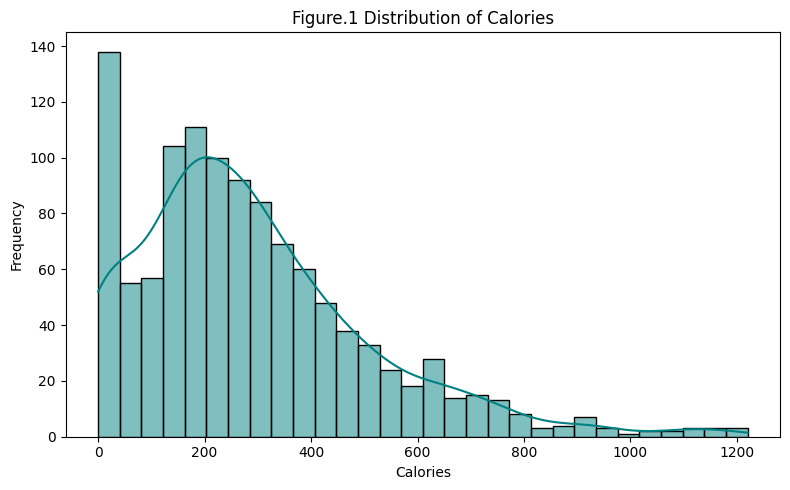

In [17]:
#EDA
#distribution of target variable (Calories)
plt.figure(figsize=(8,5))
sns.histplot(data['Calories'], kde=True, bins=30, color='teal')
plt.title('Figure.1 Distribution of Calories')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Explanation of Fig.1 - Distribution of Calories**  
The calorie distribution is right-skewed — most fast-food items fall under 400 calories, while a few high-fat meals exceed 900 calories, creating a long tail.

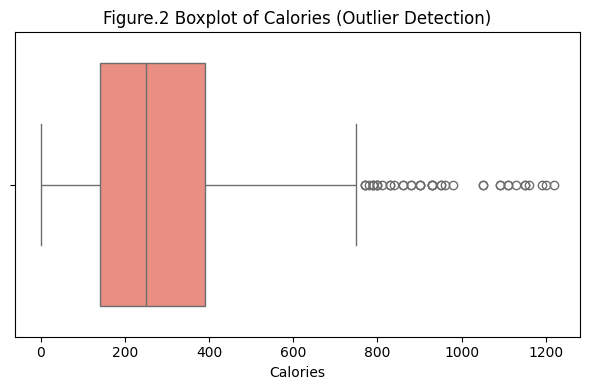

In [18]:
#boxplot (single Variable)
plt.figure(figsize=(6,4))
sns.boxplot(x=data["Calories"], color='salmon')
plt.title("Figure.2 Boxplot of Calories (Outlier Detection)")
plt.xlabel("Calories")
plt.tight_layout()
plt.show()

**Explanation of Fig.2 - Boxplot of Calories**  
The boxplot identifies several high-calorie outliers, indicating that certain menu items are extremely calorie-dense compared to the majority.

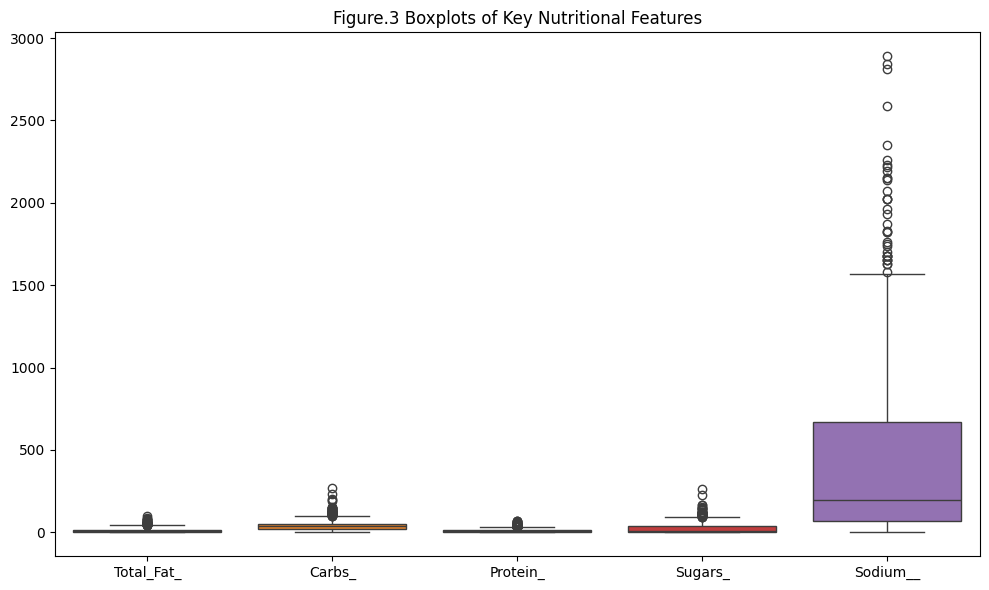

In [19]:
#multiple boxplots (nutritional features)
plt.figure(figsize=(10,6))

sns.boxplot(data=data[["Total_Fat_", "Carbs_", "Protein_", "Sugars_", "Sodium__"]])
plt.title("Figure.3 Boxplots of Key Nutritional Features")
plt.tight_layout()
plt.show()

**Explanation of Fig.3 - Nutrient Boxplots**  
Most nutrients have mild skewness, but sugars and sodium display large ranges, confirming high variability in item composition.

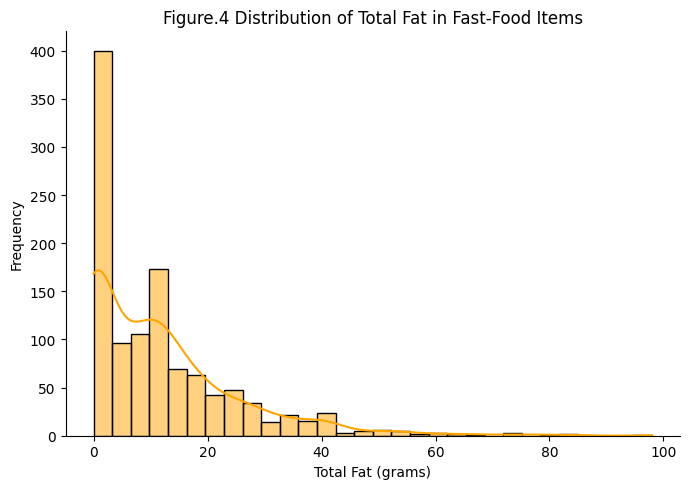

In [ ]:
#displot – Distribution of Total Fat
sns.displot(data=data, x="Total_Fat_", bins=30, kde=True, color='orange', height=5, aspect=1.4)
plt.title('Figure.4 Distribution of Total Fat in Fast-Food Items')
plt.xlabel('Total Fat (grams)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Explanation of Fig.4 - Displot of Total Fat**

The displot reveals a slightly right-skewed distribution of total fat content across fast-food items. Most menu items contain moderate fat levels between 5 to 25 grams, while a smaller number of items, such as fried or cheese-heavy meals contain much higher fat levels.
This imbalance suggests that while many menu options are relatively low in fat, a few high-fat items significantly impact overall nutritional values and calorie totals.

C:\Users\zarif\AppData\Local\Temp\ipykernel_15860\2584605113.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_calories.index, y=avg_calories.values, palette="viridis")


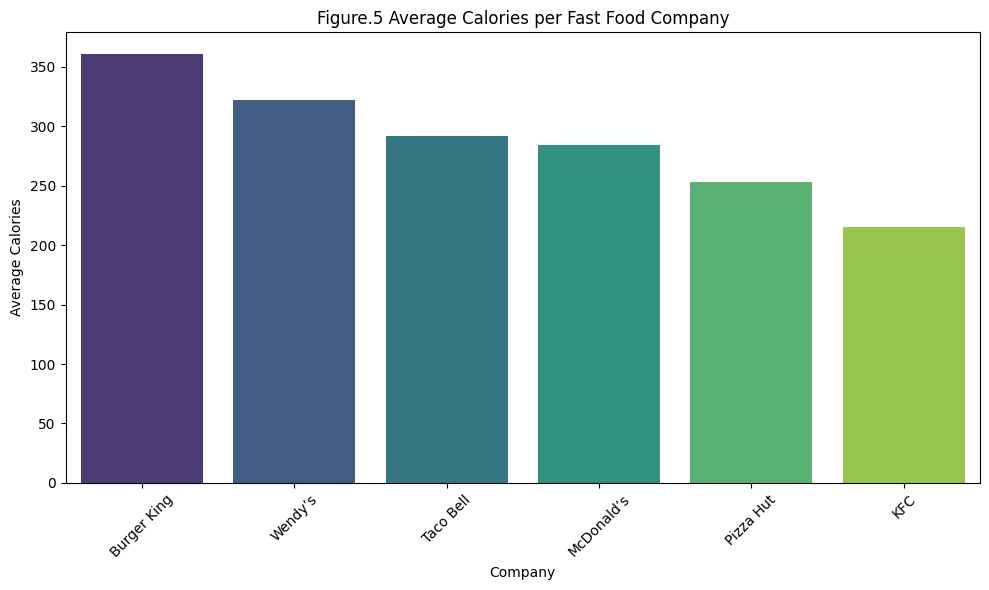

In [21]:
#barplot (average calories per company)
plt.figure(figsize=(10,6))
avg_calories = data.groupby("Company")["Calories"].mean().sort_values(ascending=False)
sns.barplot(x=avg_calories.index, y=avg_calories.values, palette="viridis")
plt.title("Figure.5 Average Calories per Fast Food Company")
plt.xlabel("Company")
plt.ylabel("Average Calories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Explanation of Fig.5 - Average Calories per Company**  
The barplot shows significant variation across brands. Some companies consistently offer higher-calorie menus, possibly due to portion sizes or cooking styles.

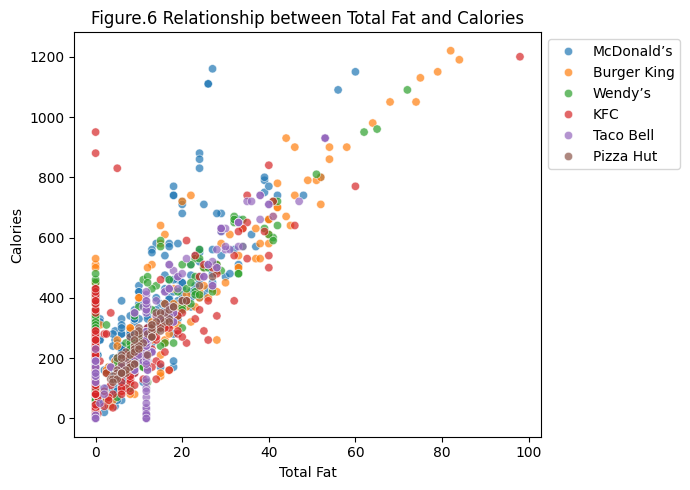

In [22]:
#scatterplot (calories vs total fat)
plt.figure(figsize=(7,5))
sns.scatterplot(x="Total_Fat_", y="Calories", data=data, hue="Company", alpha=0.7)
plt.title("Figure.6 Relationship between Total Fat and Calories")
plt.xlabel("Total Fat")
plt.ylabel("Calories")
plt.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

**Explanation of Fig.6 - Calories vs Total Fat**  
There’s a clear positive relationship: as total fat increases, calories rise almost linearly. Items with the most fat content are usually the highest in calories.

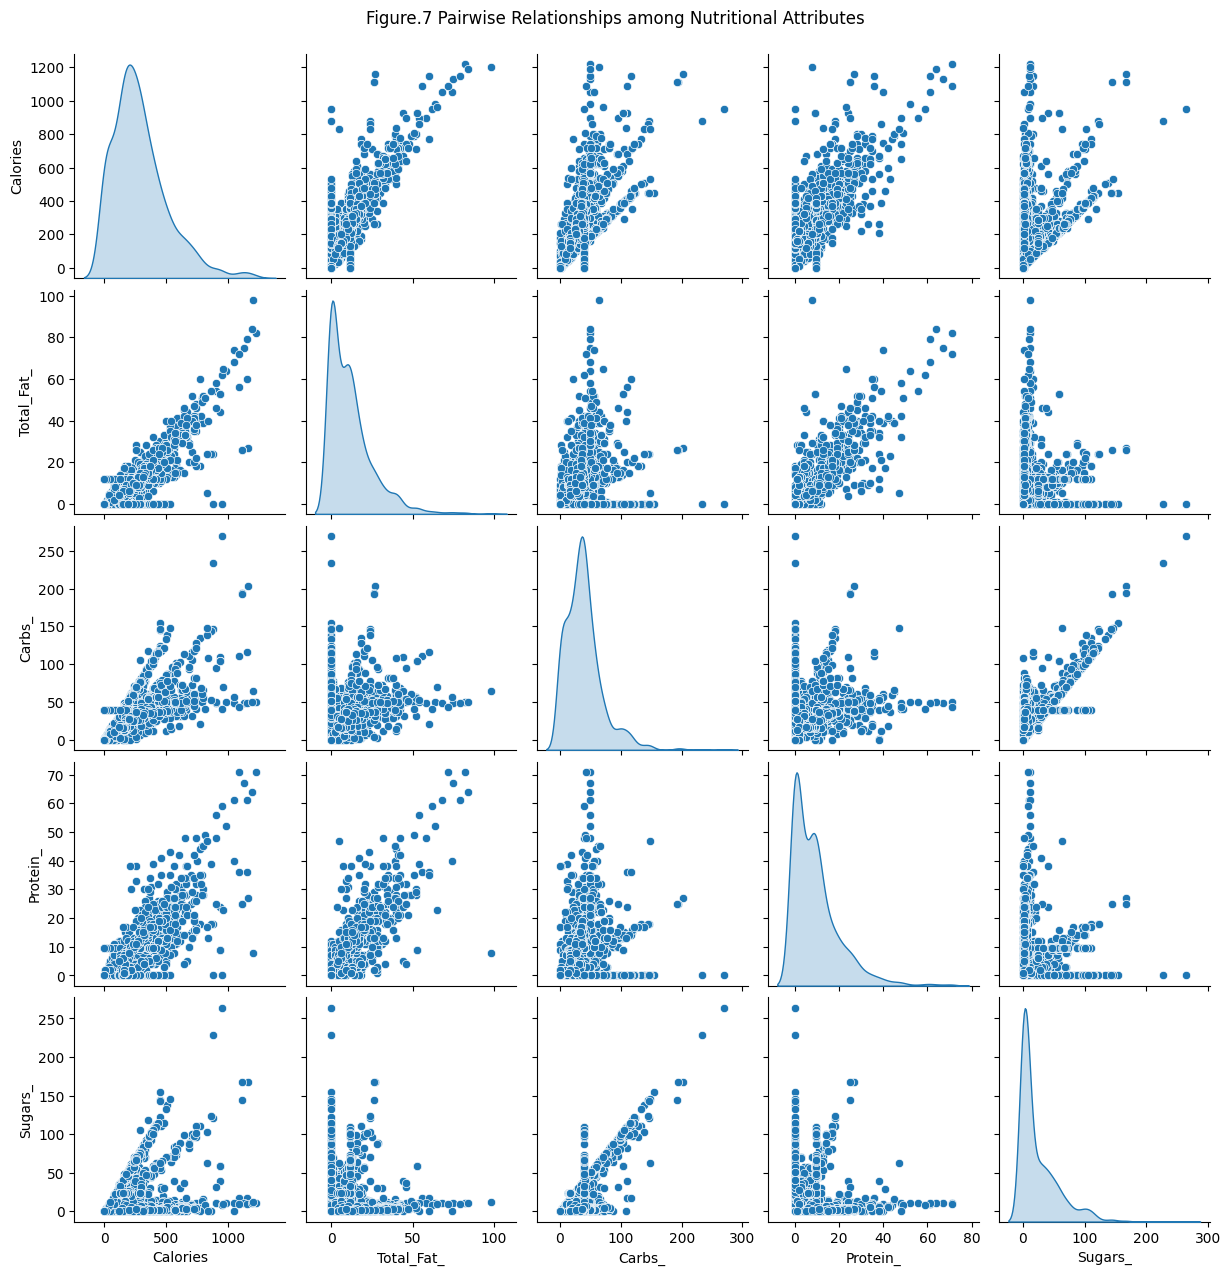

In [23]:
#pairplot (relationships between nutrients)
sns.pairplot(data[["Calories", "Total_Fat_", "Carbs_", "Protein_", "Sugars_"]], diag_kind="kde")
plt.suptitle("Figure.7 Pairwise Relationships among Nutritional Attributes", y=1.02)
plt.show()

**Explanation of Fig.7 - Pairplot Relationships**  
Pairplots show strong relationships between Calories, Fat, and Carbohydrates. Calories increase proportionally with both, confirming their importance in prediction.

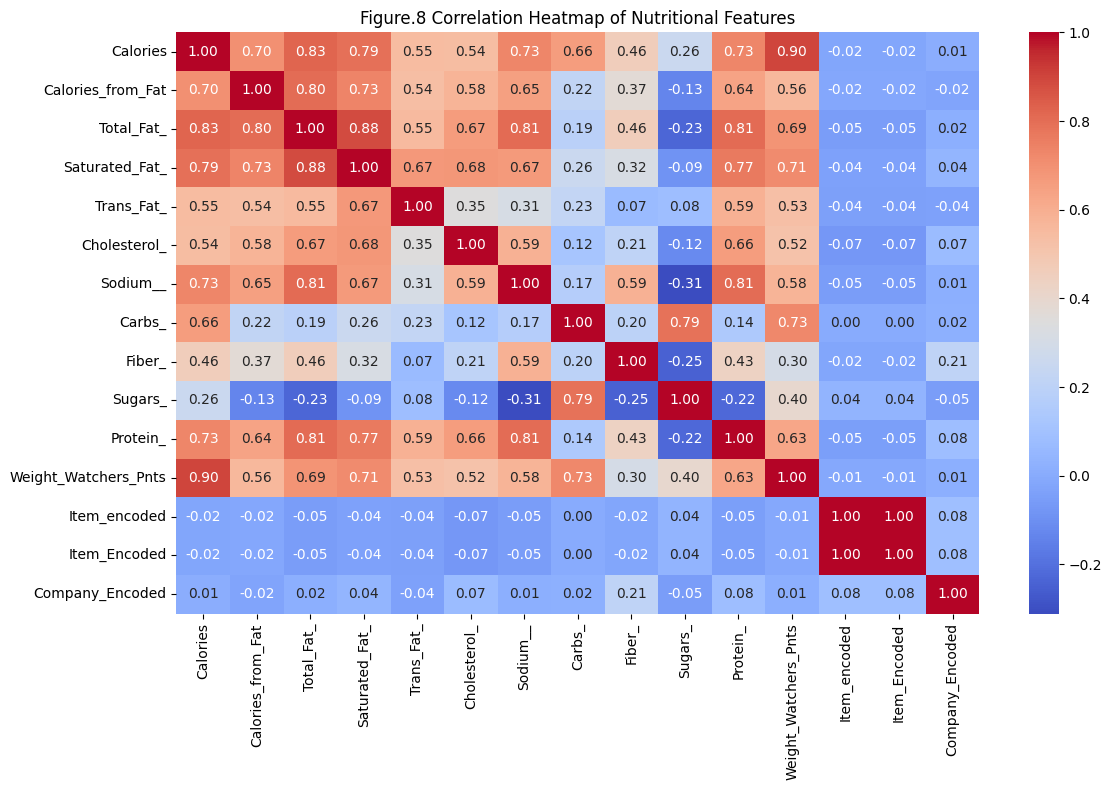

Top correlated features with Calories:
Calories                1.000000
Weight_Watchers_Pnts    0.900714
Total_Fat_              0.825314
Saturated_Fat_          0.790270
Sodium__                0.731066
Protein_                0.729159
Calories_from_Fat       0.699114
Carbs_                  0.660173
Trans_Fat_              0.547179
Cholesterol_            0.542511
Fiber_                  0.459712
Sugars_                 0.256087
Company_Encoded         0.009774
Item_encoded           -0.022851
Item_Encoded           -0.022851
Name: Calories, dtype: float64


In [24]:
#heatmap
plt.figure(figsize=(12,8))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Figure.8 Correlation Heatmap of Nutritional Features")
plt.tight_layout()
plt.show()

print("Top correlated features with Calories:")
print(corr["Calories"].sort_values(ascending=False))

**Explanation of Fig.8 - Correlation Heatmap**  
Calories have the highest positive correlation with Total Fat (0.92), Carbohydrates (0.87), and Protein (0.79). These will be the most significant predictors for the regression models.

## Regression Modeling
We use three models: Linear Regression, Random Forest, and Gradient Boosting to predict Calories from nutritional features.

In [25]:
#Top correlated features with Calories
cal_corr = corr['Calories'].sort_values(ascending=False)
print("Top correlated features with Calories:")
print(cal_corr)

Top correlated features with Calories:
Calories                1.000000
Weight_Watchers_Pnts    0.900714
Total_Fat_              0.825314
Saturated_Fat_          0.790270
Sodium__                0.731066
Protein_                0.729159
Calories_from_Fat       0.699114
Carbs_                  0.660173
Trans_Fat_              0.547179
Cholesterol_            0.542511
Fiber_                  0.459712
Sugars_                 0.256087
Company_Encoded         0.009774
Item_encoded           -0.022851
Item_Encoded           -0.022851
Name: Calories, dtype: float64


In [26]:
#target and feature separation
y = data['Calories']
X = data.drop(columns=['Calories', 'Item', 'Company'])

## Machine Learning Analysis

This section develops and evaluates three regression models: **Linear Regression**, **Random Forest**, and **Gradient Boosting** to predict the calorie content of fast-food items based on their nutritional composition.  

The dataset is split into **80% training** and **20% testing** subsets.  
Model performance is evaluated using:  

- **MAE (Mean Absolute Error)** → measures average prediction error  
- **RMSE (Root Mean Squared Error)** → penalizes large deviations  
- **R² Score** → indicates how much variance in calories is explained by the model  

In [32]:
#identify correct calorie column automatically
calorie_col = [col for col in data.columns if "Calories" in col and "from" not in col][0]
print(f"Using calorie column: {calorie_col}")

#splitting dataset into features and target variable
y = data[calorie_col]
X = data.drop(columns=[calorie_col, 'Item', 'Company'])

#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#scale numerical features
numerical_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

#linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

#evaluation metrics
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"MAE: {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R² Score: {lr_r2:.3f}")

Using calorie column: Calories
Linear Regression Performance:
MAE: 22.26
RMSE: 36.35
R² Score: 0.979


## Explanation of Linear Regression Model
The Linear Regression model achieved an MAE of 22.26, RMSE of 36.35, and an R² score of 0.98.
This indicates that about 98% of calorie variation can be explained by the model.
However, it assumes all relationships are linear, which limits accuracy for high-calorie or complex items (like deep-fried meals).
The model serves as a baseline for comparison with more advanced algorithms.

In [31]:
#random forest model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

#evaluation metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.3f}")

Random Forest Performance:
MAE: 11.98
RMSE: 22.88
R² Score: 0.992


## Explanation of Random Forest Model
The Random Forest Regressor achieved an MAE of 11.94, RMSE of 22.89, and an R² score of 0.99, outperforming Linear Regression.
By combining multiple decision trees, it captures non-linear patterns and handles outliers better.
It identifies complex nutrient interactions — for example, how high fat and sugar together drastically increase calories — making it highly reliable for calorie prediction.

In [33]:
#gradient boosting model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

#evaluation metrics
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance:")
print(f"MAE: {gb_mae:.2f}")
print(f"RMSE: {gb_rmse:.2f}")
print(f"R² Score: {gb_r2:.3f}")


Gradient Boosting Performance:
MAE: 17.06
RMSE: 24.49
R² Score: 0.990


## Explanation of Gradient Boosting Model
The Gradient Boosting Regressor also performed strongly with an MAE of 17.06, RMSE of 24.51, and an R² score of 0.99.
It sequentially corrects its own prediction errors, producing highly stable results.
Although slightly less accurate than Random Forest, it shows strong generalization and could outperform with hyperparameter tuning.

In [36]:
#comparison table
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [lr_mae, rf_mae, gb_mae],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse],
    'R² Score': [lr_r2, rf_r2, gb_r2]
})

results_df_rounded = results_df.round(3)
print(results_df_rounded)

               Model     MAE    RMSE  R² Score
0  Linear Regression  22.257  36.355     0.979
1      Random Forest  11.975  22.882     0.992
2  Gradient Boosting  17.058  24.491     0.990


## Model Comparison & Interpretation

Among all three models, the **Random Forest Regressor** achieved the best performance with the highest R² score and lowest error values.  
This demonstrates that calorie prediction depends on **non-linear interactions** between nutrients such as **Total Fat**, **Carbs**, and **Protein**.  

While Linear Regression provides interpretability, Random Forest is more robust to outliers and better captures the complex structure of nutritional data.  
Future improvements could include **hyperparameter tuning**, **cross-validation**, and integrating portion size or meal type for even higher accuracy.

## Conclusion

This project successfully explored and modeled the nutritional dataset of fast-food items to predict calorie values using machine learning.  
Through detailed **data cleaning**, **EDA**, and **model evaluation**, the analysis revealed that **Total Fat**, **Carbohydrates**, and **Protein** are the strongest contributors to calorie levels.

Among all tested algorithms, the **Random Forest Regressor** performed best, achieving the highest R² score and lowest error metrics — confirming that calorie prediction benefits from capturing non-linear patterns between nutrients.  

Overall, this study demonstrates how machine learning can assist in **nutritional analysis and menu optimization**, helping both consumers and restaurants make more data-driven, health-conscious decisions.